In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv(r'..\\data\\processed\\processed_data.csv', encoding='ISO-8859-1')

In [6]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      779425 non-null  int64  
 1   StockCode    779425 non-null  str    
 2   Description  779425 non-null  str    
 3   Quantity     779425 non-null  int64  
 4   InvoiceDate  779425 non-null  str    
 5   Price        779425 non-null  float64
 6   Customer ID  779425 non-null  float64
 7   Country      779425 non-null  str    
 8   Revenue      779425 non-null  float64
dtypes: float64(3), int64(2), str(4)
memory usage: 53.5 MB


In [8]:
df['InvoiceDate']=df['InvoiceDate'].astype('datetime64[ns]')

In [9]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [10]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'Invoice': 'nunique',
    'Revenue': 'sum'
}).reset_index()
rfm.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [11]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method="first"), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

In [12]:
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str)

In [13]:
def segment_label(row):
    r = int(row['R_score'])
    f = int(row['F_score'])
    if r >= 4 and f >= 4:
        return 'Champions'
    if r >= 3 and f >= 3:
        return 'Loyal Customers'
    if r >= 2 and f >= 2:
        return 'Potential Loyalist'
    return 'Others'

rfm['Segment'] = rfm.apply(segment_label, axis=1)
rfm['Segment'].value_counts()

Segment
Others                1838
Champions             1482
Potential Loyalist    1337
Loyal Customers       1221
Name: count, dtype: int64

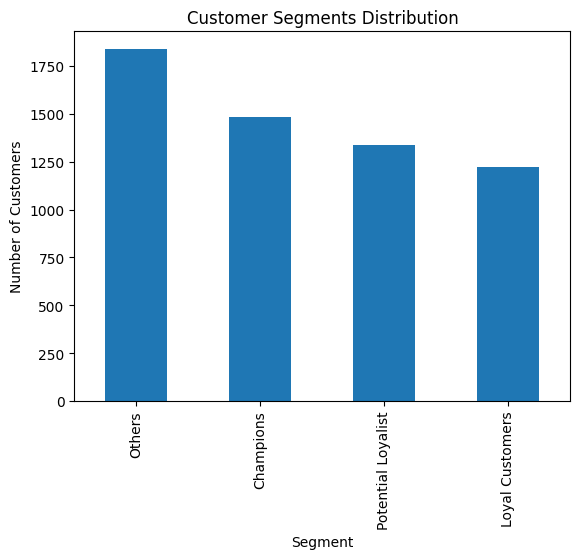

In [14]:
import matplotlib.pyplot as plt

rfm['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segments Distribution")
plt.ylabel("Number of Customers")
plt.show()

In [15]:
X = rfm[['Recency', 'Frequency', 'Monetary']]

In [16]:
%pip install -q scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\mamun\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [17]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


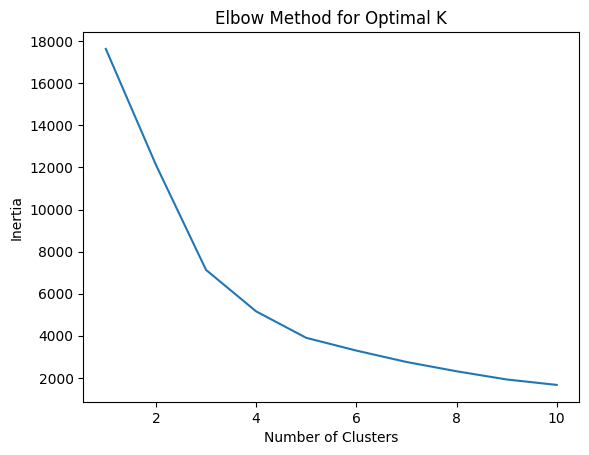

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia)
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [19]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

In [20]:
rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,66.296335,7.640239,3136.130157
1,461.861125,2.205077,747.333351
2,23.090909,143.045455,173123.584091


In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

rfm['PCA1'] = components[:, 0]
rfm['PCA2'] = components[:, 1]

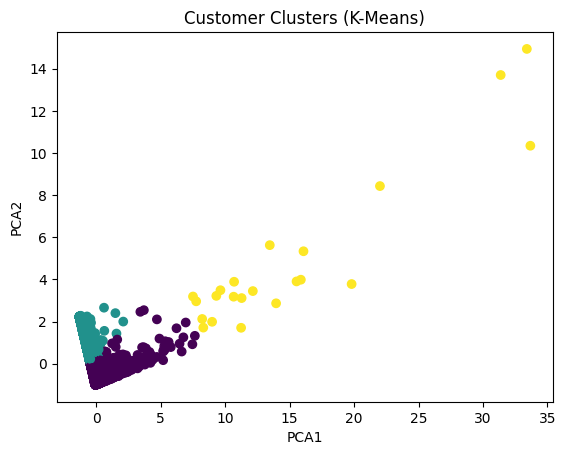

In [22]:
plt.scatter(rfm['PCA1'], rfm['PCA2'], c=rfm['Cluster'], cmap='viridis')
plt.title("Customer Clusters (K-Means)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()